# Text-Based Personality Generation using MLP

**Dataset:** Kaggle Big Five Personality Test / IPIP-FFM

This notebook demonstrates data preprocessing, feature engineering, MLP model training with Keras/TensorFlow, and short text-based personality trait description generation.

In [1]:
# Import required libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Create output directory if it doesn't exist
os.makedirs('output', exist_ok=True)

print("TensorFlow Version:", tf.__version__)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
I0000 00:00:1791277811.000919    8223 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791277811.292792    8223 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791277812.469560    8223 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fr

TensorFlow Version: 2.21.0


In [2]:
# Load dataset
df = pd.read_csv("five_big_personality_dataset.csv", sep="\t")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 1015341
Columns: 110


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [3]:
# Dataset information and basic stats
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), object(4)
memory usage: 852.1+ MB


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN7_E,OPN8_E,OPN9_E,OPN10_E,screenw,screenh,introelapse,testelapse,endelapse,IPC
count,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,...,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013275e+06,1.013275e+06,1.013275e+06,1.013558e+06,1.015341e+06,1.015341e+06
mean,2.648067e+00,2.773115e+00,3.288349e+00,3.140595e+00,3.276960e+00,2.401100e+00,2.771744e+00,3.414818e+00,2.963740e+00,3.556469e+00,...,7.689488e+03,5.423945e+03,6.325802e+03,5.336311e+03,1.149510e+03,8.262611e+02,9.590748e+02,6.754233e+02,2.701410e+03,1.045211e+01
std,1.264407e+00,1.323943e+00,1.215006e+00,1.237442e+00,1.277593e+00,1.225721e+00,1.400336e+00,1.271915e+00,1.346040e+00,1.305232e+00,...,5.841987e+05,2.629748e+05,4.298906e+05,4.408225e+05,5.600884e+02,1.802490e+02,5.104005e+04,2.017864e+04,1.483898e+06,3.982879e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-6.181300e+04,-5.001200e+04,-9.598600e+04,-3.594871e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,...,2.279000e+03,2.144000e+03,2.329000e+03,1.484000e+03,4.140000e+02,7.200000e+02,5.000000e+00,1.710000e+02,9.000000e+00,1.000000e+00
50%,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,...,3.208000e+03,3.051000e+03,3.269000e+03,2.192000e+03,1.366000e+03,7.680000e+02,1.000000e+01,2.240000e+02,1.300000e+01,1.000000e+00
75%,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,5.000000e+00,...,4.729000e+03,4.469000e+03,4.785000e+03,3.362000e+03,1.440000e+03,9.000000e+02,3.000000e+01,3.130000e+02,1.800000e+01,2.000000e+00
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,3.891434e+08,1.696693e+08,3.470326e+08,3.344289e+08,1.366000e+04,8.802000e+03,2.944307e+07,1.189272e+07,1.493327e+09,7.250000e+02


# Data Preprocessing & Cleaning

In [4]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Identify question columns
questions = [col for col in df.columns if re.match(r'^(EXT|EST|AGR|CSN|OPN)\d+$', col)]
print("Number of personality questions found:", len(questions))

# Categorize questions into factor groups
E = [c for c in questions if c.startswith('EXT')]
N = [c for c in questions if c.startswith('EST')]
A = [c for c in questions if c.startswith('AGR')]
C = [c for c in questions if c.startswith('CSN')]
O = [c for c in questions if c.startswith('OPN')]

Number of personality questions found: 50


In [5]:
# Copy data and clean invalid values / missing entries
data = df.copy()
data = data.drop_duplicates()

# Convert questionnaire columns to numeric
for col in questions:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill NaNs with median
for col in questions:
    data[col] = data[col].fillna(data[col].median())

# Keep only standard Likert scale values (1 to 5)
for col in questions:
    data = data[(data[col] >= 1) & (data[col] <= 5)]

data = data.reset_index(drop=True)
print("Cleaned Data Shape:", data.shape)

Cleaned Data Shape: (876217, 110)


In [6]:
# Reverse Scoring for Negatively Worded Questions
reverse = [
    "AGR1", "AGR3", "AGR5", "AGR7",
    "CSN2", "CSN4", "CSN6", "CSN8",
    "EXT2", "EXT4", "EXT6", "EXT8", "EXT10",
    "EST2", "EST4",
    "OPN2", "OPN4", "OPN6"
]

for col in reverse:
    if col in data.columns:
        data[col] = 6 - data[col]

print("Reverse scoring applied successfully.")

Reverse scoring applied successfully.


In [7]:
# Calculate Big Five Domain Target Scores
data['Extraversion'] = data[E].mean(axis=1)
data['Neuroticism'] = data[N].mean(axis=1)
data['Agreeableness'] = data[A].mean(axis=1)
data['Conscientiousness'] = data[C].mean(axis=1)
data['Openness'] = data[O].mean(axis=1)

traits = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']
display(data[traits].head())

,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
0,4.5,3.2,4.6,3.9,2.4
1,3.5,3.7,2.0,4.4,2.5
2,4.1,3.4,2.5,4.2,2.6
3,3.9,2.5,2.6,3.8,2.9
4,4.8,4.8,2.9,4.6,1.9


<Figure size 864x576 with 0 Axes>

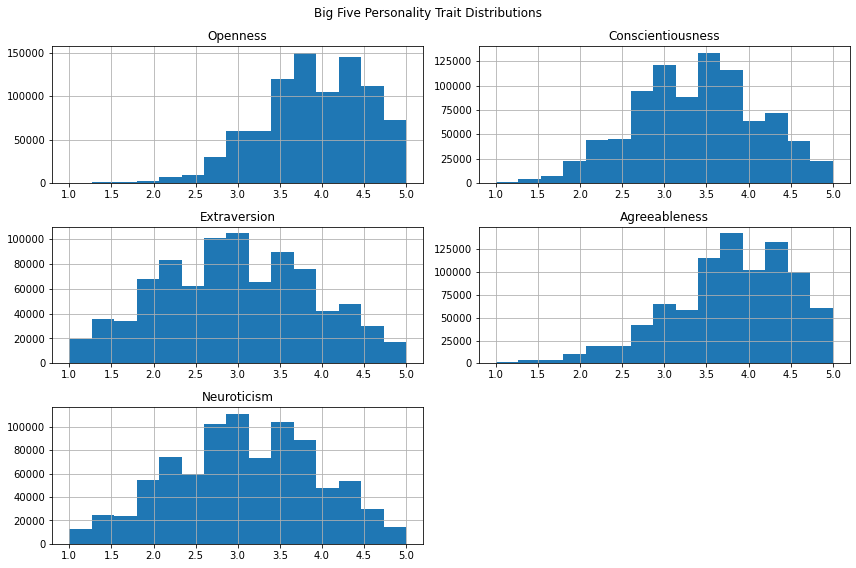

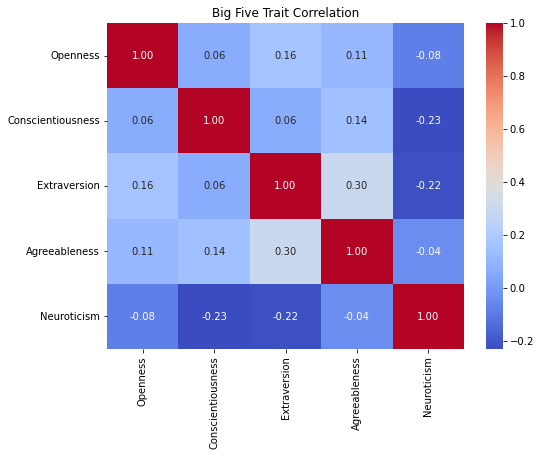

In [8]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(12, 8))
data[traits].hist(figsize=(12, 8), bins=15)
plt.suptitle("Big Five Personality Trait Distributions")
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data[traits].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Big Five Trait Correlation")
plt.show()

# Dataset Splitting & Preprocessing Pipeline

In [9]:
# Define Input (X) and Output (y)
X = data[questions]
y = data[traits]

# Split into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Input Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Scaler & Preprocessed Datasets
joblib.dump(scaler, "output/scaler.pkl")
data.to_csv("output/processed_personality_data.csv", index=False)
np.save("output/X_train.npy", X_train_scaled)
np.save("output/X_test.npy", X_test_scaled)
y_train.to_csv("output/y_train.csv", index=False)
y_test.to_csv("output/y_test.csv", index=False)

print("Data preprocessing and export finished.")

Data preprocessing and export finished.


# Multi-Layer Perceptron (MLP) Model Building & Training

In [10]:
# Build Multi-Layer Perceptron (MLP) Neural Network Architecture
def build_mlp_model(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(output_dim, activation='linear')  # Regression output for trait scores
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

mlp_model = build_mlp_model(X_train_scaled.shape[1], y_train.shape[1])
mlp_model.summary()

/home/mmcoe/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1791277938.345771    8223 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,029 (66.52 KB)

 Trainable params: 17,029 (66.52 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train MLP Model

history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    verbose=1
)

# Save Trained Model
mlp_model.save("output/mlp_personality_model.h5")
print("Model saved to output/mlp_personality_model.h5")

Epoch 1/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0063 - mae: 0.0530 - val_loss: 0.0397 - val_mae: 0.1543
Epoch 2/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0062 - mae: 0.0524 - val_loss: 0.0395 - val_mae: 0.1545
Epoch 3/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0061 - mae: 0.0517 - val_loss: 0.0385 - val_mae: 0.1545
Epoch 4/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0060 - mae: 0.0508 - val_loss: 0.0390 - val_mae: 0.1549
Epoch 5/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0059 - mae: 0.0502 - val_loss: 0.0417 - val_mae: 0.1579
Epoch 6/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0058 - mae: 0.0499 - val_loss: 0.0415 - val_mae: 0.1591
Epoch 7/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0058 - mae: 0.0497 - val_loss: 0.0419 - val_mae: 0.1587
Epoch 8/30
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0058 - mae: 0.0498 - val_loss: 0.0456 - val_mae: 0.1638
Epoch 9/30
2191/2191 ━━━━━━━━━━━━━━━━━━━

Model saved to output/mlp_personality_model.h5


In [15]:
# Evaluate Model
y_pred = mlp_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test Mean Squared Error (MSE): {mse:.4f}")
print(f"Test R2 Score: {r2:.4f}")

5477/5477 ━━━━━━━━━━━━━━━━━━━━ 2s 322us/step
Test Mean Squared Error (MSE): 0.0647
Test R2 Score: 0.8988


# Text-Based Personality Description Generation

In [16]:
# Categorize individual scores
def get_trait_level(score):
    if score < 2.5:
        return "Low"
    elif score < 3.5:
        return "Medium"
    else:
        return "High"

# Trait Description Mapping Dictionary
trait_descriptions = {
    'Openness': {
        'Low': "pragmatic, routine-oriented, and prefers familiar experiences",
        'Medium': "balanced between traditional practical routines and trying new creative ideas",
        'High': "highly imaginative, curious, creative, and open to novel ideas"
    },
    'Conscientiousness': {
        'Low': "spontaneous, flexible, and occasionally relaxed about structure",
        'Medium': "reasonably organized and reliable while maintaining flexibility",
        'High': "highly organized, disciplined, goal-driven, and meticulous"
    },
    'Extraversion': {
        'Low': "introverted, reflective, and energized by quiet solitude",
        'Medium': "ambiverted, comfortable in both social settings and quiet environments",
        'High': "outgoing, energetic, social, and assertive in group settings"
    },
    'Agreeableness': {
        'Low': "competitive, skeptical, direct, and independent in decision-making",
        'Medium': "cooperative and straightforward while knowing when to hold their ground",
        'High': "compassionate, empathetic, cooperative, and helpful toward others"
    },
    'Neuroticism': {
        'Low': "emotionally resilient, calm under pressure, and stable",
        'Medium': "generally balanced emotionally with occasional stress under pressure",
        'High': "sensitive, emotionally reactive, and prone to experiencing stress"
    }
}

# Generator Function
def generate_personality_summary(trait_scores):
    """
    Accepts a dictionary of trait scores or numpy array and generates a short descriptive personality summary.
    """
    summary_parts = []
    for trait, score in trait_scores.items():
        level = get_trait_level(score)
        desc = trait_descriptions[trait][level]
        summary_parts.append(f"{trait} ({level}): {desc}")
    
    full_text = "Personality Trait Overview:\n" + "\n".join([f"- {p}" for p in summary_parts])
    return full_text

In [17]:
# Test Output Generation on Sample Predictions
sample_input = X_test_scaled[:1]
predicted_scores = mlp_model.predict(sample_input)[0]

predicted_dict = dict(zip(traits, predicted_scores))

print("Predicted Scores:")
for t, s in predicted_dict.items():
    print(f"{t}: {s:.2f}")

print("\nGenerated Text Profile:")
print(generate_personality_summary(predicted_dict))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Scores:
Openness: 3.96
Conscientiousness: 3.58
Extraversion: 4.01
Agreeableness: 3.67
Neuroticism: 2.20

Generated Text Profile:
Personality Trait Overview:
- Openness (High): highly imaginative, curious, creative, and open to novel ideas
- Conscientiousness (High): highly organized, disciplined, goal-driven, and meticulous
- Extraversion (High): outgoing, energetic, social, and assertive in group settings
- Agreeableness (High): compassionate, empathetic, cooperative, and helpful toward others
- Neuroticism (Low): emotionally resilient, calm under pressure, and stable
